Opening input datasets...
Reading raster metadata...
GeoTransform: (718854.2985965945, 15.0, 0.0, 3514673.532497386, 0.0, -15.0)
Projection: PROJCS["WGS_1984_UTM_Zone_46N",GEOGCS["WGS 84",DAT...
Computing inverse geotransform...
Inverse GeoTransform: (-47923.619906439635, 0.06666666666666667, 0.0, 234311.56883315908, 0.0, -0.06666666666666667)
Creating output dataset...
Reading displacement fields...
VX range: 0.00 to 135.65
VY range: 0.00 to 135.65
VX NaN count: 0
VY NaN count: 0
NaN values in displacement fields replaced with 0
Processing 1 bands...

Processing band 1/1...
Band 1 NoData value: 0.0
  Row 0/709 (0.0%)
  Row 70/709 (9.9%)
  Row 140/709 (19.7%)
  Row 210/709 (29.6%)
  Row 280/709 (39.5%)
  Row 350/709 (49.4%)
  Row 420/709 (59.2%)
  Row 490/709 (69.1%)
  Row 560/709 (79.0%)
  Row 630/709 (88.9%)
  Row 700/709 (98.7%)
Writing band 1 to output...
Processing finished. Cleaning up resources...

Visualizing results...
Displaying original image...


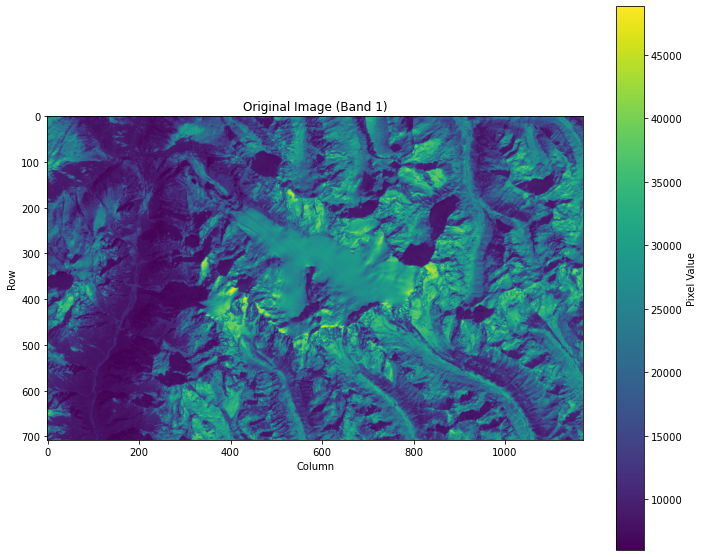

Displaying warped image...


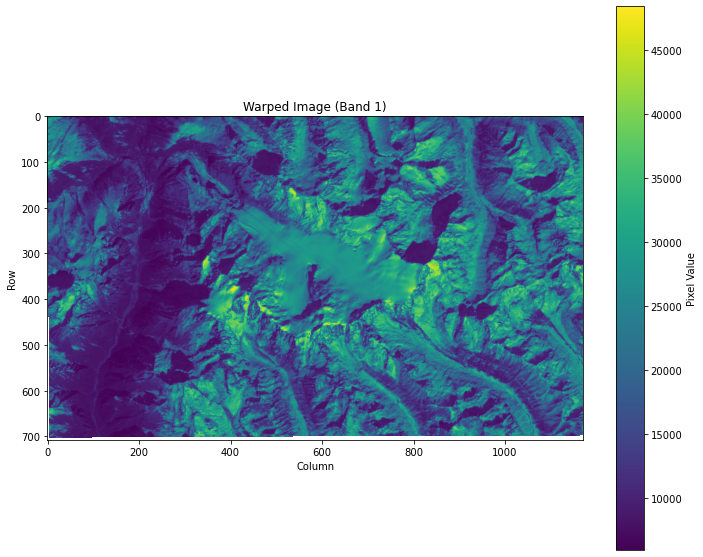

Displaying X displacement...


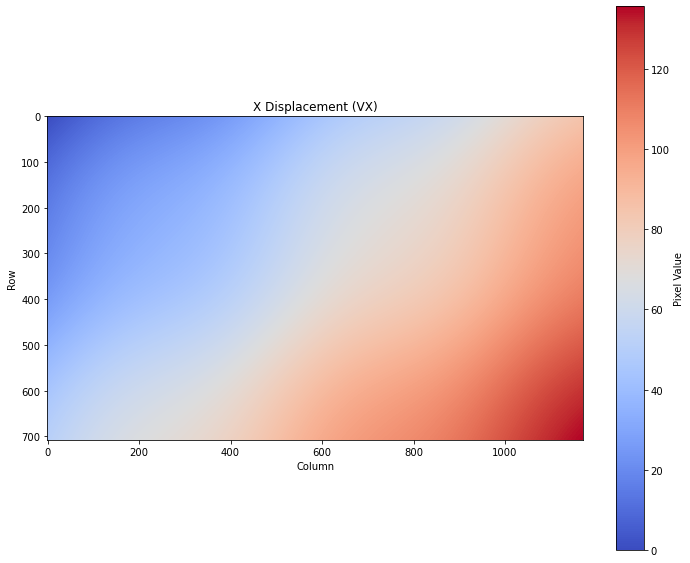

Displaying Y displacement...


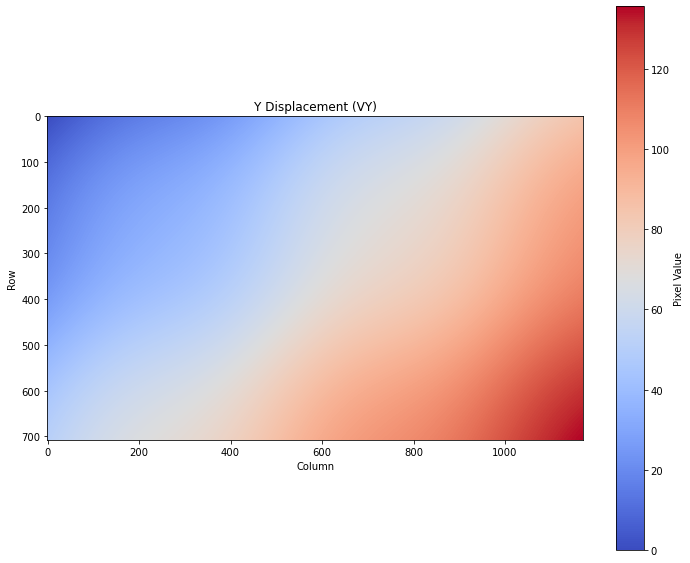

Done! Output saved to: D:\yan2\github\1.Simulated image\T500vvsin_moveextentL9.tif


In [1]:
import numpy as np
from osgeo import gdal, osr
import matplotlib.pyplot as plt
import math

def sinc(x):
    if x == 0:
        return 1.0
    else:
        return math.sin(math.pi * x) / (math.pi * x)

def limit_coord(val, max_val):
    return max(0, min(max_val - 1, val))

def sinc_interpolation(in_array, src_x, src_y, nodata=None):
    rows, cols = in_array.shape

    x0 = int(math.floor(src_x))
    y0 = int(math.floor(src_y))

    u = src_x - x0
    v = src_y - y0

    total_value = 0.0
    total_weight = 0.0

    window_size = 4
    half_window = window_size // 2

    for ii in range(-half_window, half_window):
        for jj in range(-half_window, half_window):
            x_neighbor = x0 + jj
            y_neighbor = y0 + ii

            x_idx = limit_coord(x_neighbor, cols)
            y_idx = limit_coord(y_neighbor, rows)

            pixel_value = in_array[y_idx, x_idx]

            if nodata is not None and pixel_value == nodata:
                continue

            wx = sinc(jj - u)
            wy = sinc(ii - v)
            weight = wx * wy

            total_value += weight * pixel_value
            total_weight += weight

    if total_weight == 0:
        return np.nan
    else:
        return total_value / total_weight


input_tif = r"D:\yan2\github\1.Simulated image\extentL9.tif"
vx_tif = r"D:\yan2\github\1.Simulated image\T500uxsin.tif"
vy_tif = r"D:\yan2\github\1.Simulated image\T500uysin.tif"
output_tif = r"D:\yan2\github\1.Simulated image\T500vvsin_moveextentL9.tif"

print("Opening input datasets...")
input_ds = gdal.Open(input_tif, gdal.GA_ReadOnly)
vx_ds = gdal.Open(vx_tif, gdal.GA_ReadOnly)
vy_ds = gdal.Open(vy_tif, gdal.GA_ReadOnly)

if input_ds is None:
    raise FileNotFoundError(f"Cannot open input image: {input_tif}")
if vx_ds is None:
    raise FileNotFoundError(f"Cannot open X displacement: {vx_tif}")
if vy_ds is None:
    raise FileNotFoundError(f"Cannot open Y displacement: {vy_tif}")

print("Reading raster metadata...")

cols = input_ds.RasterXSize
rows = input_ds.RasterYSize
num_bands = input_ds.RasterCount

geotransform = input_ds.GetGeoTransform()
print(f"GeoTransform: {geotransform}")

projection = input_ds.GetProjection()
print(f"Projection: {projection[:50]}...")

if (vx_ds.RasterXSize != cols or vx_ds.RasterYSize != rows or
    vy_ds.RasterXSize != cols or vy_ds.RasterYSize != rows):
    raise ValueError("Displacement field size does not match input image.")

print("Computing inverse geotransform...")

inv_geotransform = gdal.InvGeoTransform(geotransform)
if inv_geotransform is None:
    raise RuntimeError("Failed to compute inverse geotransform.")
print(f"Inverse GeoTransform: {inv_geotransform}")

print("Creating output dataset...")

driver = gdal.GetDriverByName('GTiff')

output_ds = driver.Create(
    output_tif,
    cols,
    rows,
    num_bands,
    gdal.GDT_Float32
)

output_ds.SetGeoTransform(geotransform)
output_ds.SetProjection(projection)

print("Reading displacement fields...")
vx_band = vx_ds.GetRasterBand(1)
vy_band = vy_ds.GetRasterBand(1)

vx_array = vx_band.ReadAsArray()
vy_array = vy_band.ReadAsArray()

print(f"VX range: {np.nanmin(vx_array):.2f} to {np.nanmax(vx_array):.2f}")
print(f"VY range: {np.nanmin(vy_array):.2f} to {np.nanmax(vy_array):.2f}")

print(f"VX NaN count: {np.sum(np.isnan(vx_array))}")
print(f"VY NaN count: {np.sum(np.isnan(vy_array))}")

vx_array = np.nan_to_num(vx_array)
vy_array = np.nan_to_num(vy_array)
print("NaN values in displacement fields replaced with 0")

print(f"Processing {num_bands} bands...")

for band_idx in range(1, num_bands + 1):
    print(f"\nProcessing band {band_idx}/{num_bands}...")

    in_band = input_ds.GetRasterBand(band_idx)
    in_array = in_band.ReadAsArray()

    nodata = in_band.GetNoDataValue()
    print(f"Band {band_idx} NoData value: {nodata}")

    out_array = np.full((rows, cols), np.nan, dtype=np.float32)

    for y in range(rows):
        if y % max(1, rows//10) == 0:
            print(f"  Row {y}/{rows} ({(y/rows)*100:.1f}%)")

        for x in range(cols):
            geo_x = geotransform[0] + x * geotransform[1] + y * geotransform[2]
            geo_y = geotransform[3] + x * geotransform[4] + y * geotransform[5]

            src_geo_x = geo_x - vx_array[y, x]
            src_geo_y = geo_y - vy_array[y, x]

            src_x = (inv_geotransform[0] +
                     inv_geotransform[1] * src_geo_x +
                     inv_geotransform[2] * src_geo_y)

            src_y = (inv_geotransform[3] +
                     inv_geotransform[4] * src_geo_x +
                     inv_geotransform[5] * src_geo_y)

            if np.isnan(src_x) or np.isnan(src_y):
                continue

            if src_x < -1 or src_x > cols or src_y < -1 or src_y > rows:
                continue

            try:
                value = sinc_interpolation(in_array, src_x, src_y, nodata)
                if not np.isnan(value):
                    out_array[y, x] = value
            except Exception:
                continue

    print(f"Writing band {band_idx} to output...")
    out_band = output_ds.GetRasterBand(band_idx)
    out_band.WriteArray(out_array)

    if nodata is not None:
        out_band.SetNoDataValue(float(nodata))

    out_band.FlushCache()

print("Processing finished. Cleaning up resources...")

del input_ds, vx_ds, vy_ds, output_ds

print("\nVisualizing results...")

def plot_raster(path, title, band=1, cmap='viridis'):
    ds = gdal.Open(path)
    band = ds.GetRasterBand(band)
    arr = band.ReadAsArray()

    plt.figure(figsize=(12, 10))
    plt.imshow(arr, cmap=cmap)
    plt.colorbar(label='Pixel Value')
    plt.title(title)
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.show()

print("Displaying original image...")
plot_raster(input_tif, "Original Image (Band 1)")

print("Displaying warped image...")
plot_raster(output_tif, "Warped Image (Band 1)")

print("Displaying X displacement...")
plot_raster(vx_tif, "X Displacement (VX)", cmap='coolwarm')

print("Displaying Y displacement...")
plot_raster(vy_tif, "Y Displacement (VY)", cmap='coolwarm')

print("Done! Output saved to:", output_tif)

In [4]:
import math

def calculate_V(i, j, T_i, T_j):
    """
    计算函数 V = 0.1*i + 0.1*j + 3*sin(i/T_i * 2π) + 3*sin(j/T_j * 2π)
    
    参数:
    i, j: 输入变量
    T_i, T_j: 周期参数
    
    返回:
    V: 计算结果
    """
    # 计算函数值
    V = 0.1 * i + 0.1 * j + 3 * math.sin(i / T_i * 2 * math.pi) + 3 * math.sin(j / T_j * 2 * math.pi)
    
    return V

# 示例使用
if __name__ == "__main__":
    # 输入i, j和周期参数
    i = float(input("请输入i的值: "))
    j = float(input("请输入j的值: "))
    T_i = float(input("请输入T_i的值: "))
    T_j = float(input("请输入T_j的值: "))
    
    # 计算结果
    result = calculate_V(i, j, T_i, T_j)
    
    print(f"当 i={i}, j={j}, T_i={T_i}, T_j={T_j} 时:")
    print(f"V = {result:.4f}")

当 i=1171.0, j=709.0, T_i=500.0, T_j=500.0 时:
V = 191.9908
